## 3.1 サイコロ問題

4, 6, 8, 12, 20面のサイコロの入った箱を持っている。箱から、サイコロをランダムに取り出し、振って６が出たとする。各サイコロを振った確率を求める。

## 仮説

H1 = 4面

H2 = 6面

H3 = 8面

H4 = 12面

H5 = 20面

## 事前確率
どれも同じ確率で選ばれる

$ p(H) = 1/5 $

## 観測データ

D = 6が出た

## 尤度

4面サイコロ： $ p(D|4) = 0 $

6面サイコロ： $ p(D|6) = 1/6 $

8面サイコロ： $ p(D|8) = 1/8 $

12面サイコロ： $ p(D|12) = 1/12 $

20面サイコロ： $ p(D|20) = 1/20 $



In [1]:
# ==================================
# サイコロ問題
# 6が出た
# ==================================

# 仮説（サイコロの面数）

hypotheses = [4, 6, 8, 12, 20]

# -------------------------
# 事前確率
# -------------------------

prior = {}

for h in hypotheses:
    prior[h] = 1 / len(hypotheses)

# -------------------------
# 尤度
# -------------------------

likelihood = {}

for h in hypotheses:

    if h < 6:
        likelihood[h] = 0
    else:
        likelihood[h] = 1 / h

# -------------------------
# 非正規化事後確率
# -------------------------

posterior = {}

for h in hypotheses:
    posterior[h] = prior[h] * likelihood[h]

# -------------------------
# 正規化
# -------------------------

evidence = sum(posterior.values())

for h in hypotheses:
    posterior[h] /= evidence

# -------------------------
# 結果表示
# -------------------------

print("事後確率")

for h in hypotheses:
    print(f"{h:2d}面サイコロ : {posterior[h]:.4f}")

事後確率
 4面サイコロ : 0.0000
 6面サイコロ : 0.3922
 8面サイコロ : 0.2941
12面サイコロ : 0.1961
20面サイコロ : 0.1176


### 次に、6,　8,　7,　7,　5,　4 が出たとする。



In [2]:
# =====================================
# Dice Problem
# 観測: 6,6,8,7,7,5,4
# =====================================

hypotheses = [4, 6, 8, 12, 20]

# 初期事前確率
posterior = {h: 1/len(hypotheses) for h in hypotheses}

data = [6, 6, 8, 7, 7, 5, 4]

for roll in data:

    # 尤度を掛ける
    for h in hypotheses:

        if roll > h:
            likelihood = 0
        else:
            likelihood = 1 / h

        posterior[h] *= likelihood

    # 正規化
    evidence = sum(posterior.values())

    for h in hypotheses:
        posterior[h] /= evidence

    print(f"\n{roll} が出た後")

    for h in hypotheses:
        print(f"{h:2d}面 : {posterior[h]:.6f}")

# 最終結果
print("\n最終結果")
for h in hypotheses:
    print(f"{h:2d}面 : {posterior[h]:.6f}")


6 が出た後
 4面 : 0.000000
 6面 : 0.392157
 8面 : 0.294118
12面 : 0.196078
20面 : 0.117647

6 が出た後
 4面 : 0.000000
 6面 : 0.525624
 8面 : 0.295664
12面 : 0.131406
20面 : 0.047306

8 が出た後
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.735134
12面 : 0.217817
20面 : 0.047049

7 が出た後
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.817574
12面 : 0.161496
20面 : 0.020930

7 が出た後
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.875713
12面 : 0.115320
20面 : 0.008967

5 が出た後
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.915845
12面 : 0.080403
20面 : 0.003751

4 が出た後
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.943248
12面 : 0.055206
20面 : 0.001545

最終結果
 4面 : 0.000000
 6面 : 0.000000
 8面 : 0.943248
12面 : 0.055206
20面 : 0.001545


In [3]:
from thinkbayes import Suite

class Dice(Suite):

    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1 / hypo


suite = Dice([4, 6, 8, 12, 20])

for roll in [6, 6, 8, 7, 7, 5, 4]:
    suite.Update(roll)

for hypo in suite.Values():
    print(hypo, suite.Prob(hypo))

4 0.0
6 0.0
8 0.9432484536722124
12 0.055206128061290875
20 0.001545418266496554


### 3.2 機関車問題

ある鉄道会社では、機関車に 1...N という番号を付けている。ある日、60 番という機関車を目撃したとすると、鉄道会社は何台の機関車を所有しているのか推測せよ。

1. このデータを見る前にNについて何を知っていたか。

Nは、１から１０００までの範囲ではどれも同じくらいと仮定。

事前確率： $ hypos = xrange(1, 1001) $

2. Nが与えられたとしたら、データ（６０番目の機関車）を目撃する機会はどのようなものか。

N両の機関車の車両を仮定したとすると、６０番目を目撃する確率はどのぐらいか。

尤度： 



In [4]:
import numpy as np


hypos = np.arange(1, 1001)
data = 60


class Train(Suite):

    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1.0 / hypo

suite = Train(hypos)
suite.Update(60)

0.0028222671142652746

In [5]:
def Mean(suite):
    total = 0
    for hypo, prob in suite.Items():
        total += hypo*prob
    return total

Mean(suite)

333.41989326371095

In [6]:
for data in [60,30,90]:
    suite.Update(data)


Mean(suite)

133.27523137503118

MAP推定値 = 60
事後平均 = 333.4


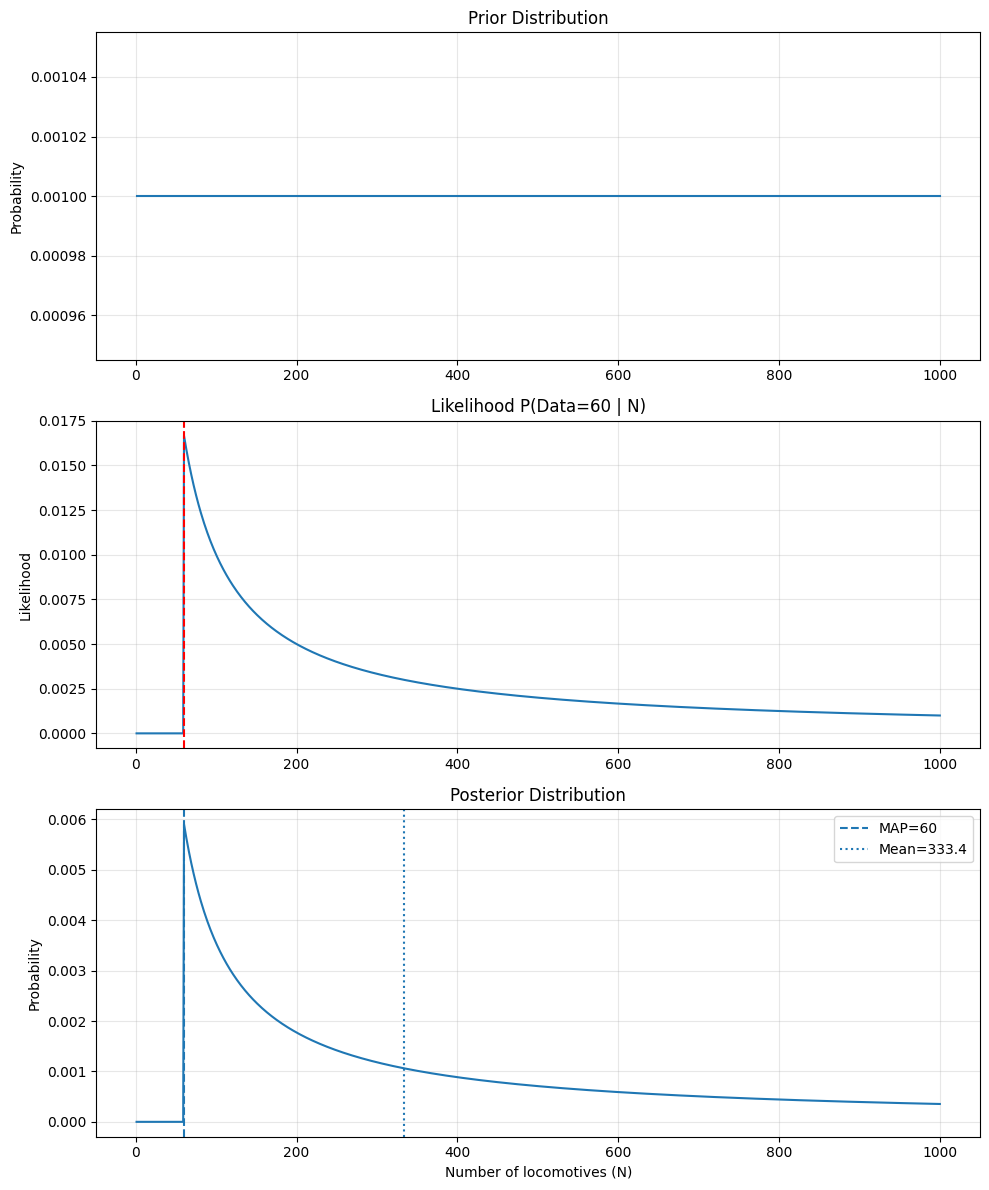

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 仮説空間
# -----------------------------
N = np.arange(1, 1001)

# -----------------------------
# 事前分布
# -----------------------------
prior = np.ones_like(N, dtype=float)
prior /= prior.sum()

# -----------------------------
# 尤度 P(data=60 | N)
# -----------------------------
likelihood = np.where(N >= 60, 1 / N, 0)

# -----------------------------
# 事後分布
# -----------------------------
posterior = prior * likelihood
posterior /= posterior.sum()

# -----------------------------
# 代表値
# -----------------------------
map_estimate = N[np.argmax(posterior)]
mean_estimate = np.sum(N * posterior)

print(f"MAP推定値 = {map_estimate}")
print(f"事後平均 = {mean_estimate:.1f}")

# -----------------------------
# グラフ
# -----------------------------
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

# 事前分布
ax[0].plot(N, prior)
ax[0].set_title("Prior Distribution")
ax[0].set_ylabel("Probability")
ax[0].grid(alpha=0.3)

# 尤度
ax[1].plot(N, likelihood)
ax[1].axvline(60, color='red', linestyle='--')
ax[1].set_title("Likelihood P(Data=60 | N)")
ax[1].set_ylabel("Likelihood")
ax[1].grid(alpha=0.3)

# 事後分布
ax[2].plot(N, posterior)

ax[2].axvline(
    map_estimate,
    linestyle='--',
    label=f"MAP={map_estimate}"
)

ax[2].axvline(
    mean_estimate,
    linestyle=':',
    label=f"Mean={mean_estimate:.1f}"
)

ax[2].set_title("Posterior Distribution")
ax[2].set_xlabel("Number of locomotives (N)")
ax[2].set_ylabel("Probability")
ax[2].legend()
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 

In [8]:
import numpy as np
from scipy.special import comb

# -----------------------------
# 目撃した機関車番号
# -----------------------------
observed = [30, 60, 90]
k = len(observed)
m = max(observed)

# -----------------------------
# 上限ごとに計算
# -----------------------------
for N_max in [500, 1000, 2000]:

    N = np.arange(1, N_max + 1)

    # 尤度
    likelihood = np.zeros_like(N, dtype=float)

    mask = N >= m

    likelihood[mask] = 1 / comb(N[mask], k)

    # 一様事前分布
    prior = np.ones_like(N, dtype=float)
    prior /= prior.sum()

    # 事後分布
    posterior = prior * likelihood
    posterior /= posterior.sum()

    # 事後期待値
    posterior_mean = np.sum(N * posterior)

    # MAP
    map_estimate = N[np.argmax(posterior)]

    print(f"\nN_max = {N_max}")
    print(f"MAP estimate      = {map_estimate:.0f}")
    print(f"Posterior Mean    = {posterior_mean:.2f}")


N_max = 500
MAP estimate      = 90
Posterior Mean    = 151.36

N_max = 1000
MAP estimate      = 90
Posterior Mean    = 163.60

N_max = 2000
MAP estimate      = 90
Posterior Mean    = 170.50


MAP = 90
Posterior Mean = 163.60


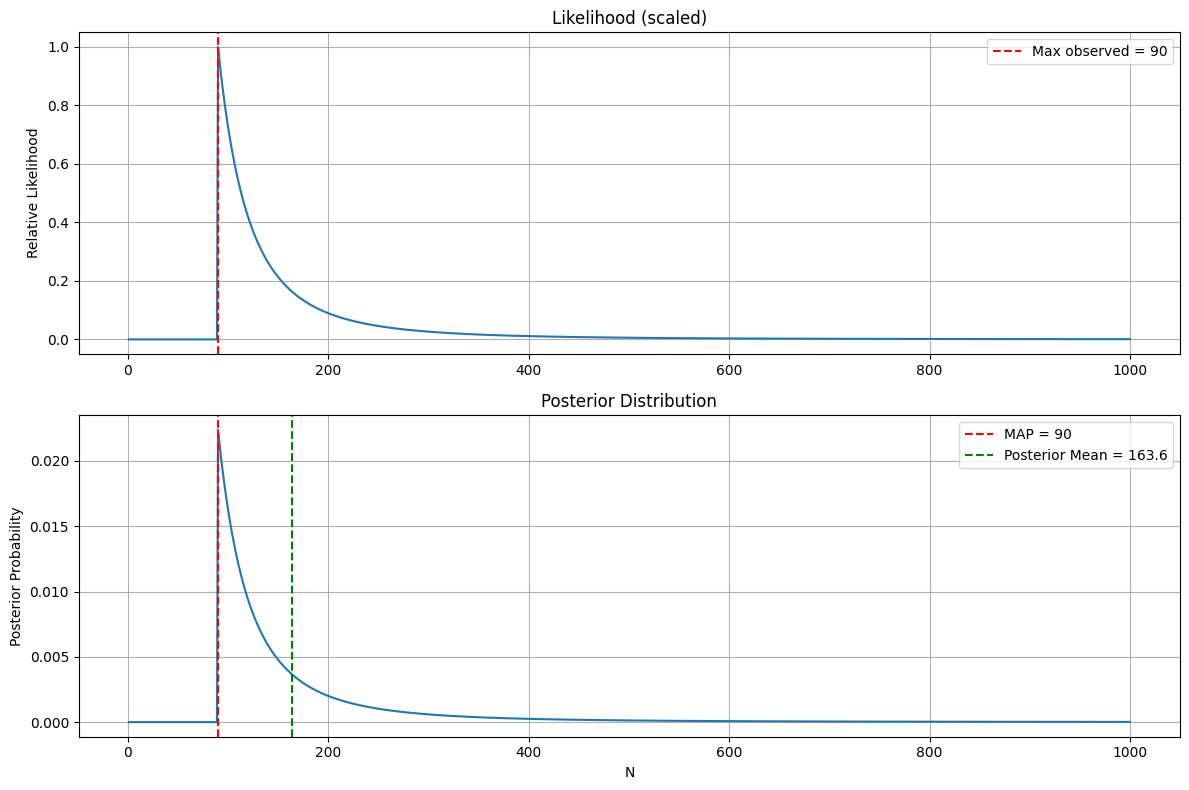

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# -----------------------------
# 観測データ
# -----------------------------
observed = [30, 60, 90]

m = max(observed)
k = len(observed)

# -----------------------------
# N の上限
# -----------------------------
N_max = 1000

N = np.arange(1, N_max + 1)

# -----------------------------
# 尤度
# P(D|N)=1/C(N,k)
# -----------------------------
likelihood = np.zeros_like(N, dtype=float)

mask = N >= m

likelihood[mask] = 1 / comb(N[mask], k)

# グラフを見やすくするため最大値で割る
likelihood_scaled = likelihood / likelihood.max()

# -----------------------------
# 一様事前分布
# -----------------------------
prior = np.ones_like(N, dtype=float)
prior /= prior.sum()

# -----------------------------
# 事後分布
# -----------------------------
posterior = prior * likelihood
posterior /= posterior.sum()

# -----------------------------
# 事後期待値
# -----------------------------
posterior_mean = np.sum(N * posterior)

# MAP推定
# -----------------------------
map_estimate = N[np.argmax(posterior)]

print(f"MAP = {map_estimate}")
print(f"Posterior Mean = {posterior_mean:.2f}")

# -----------------------------
# グラフ
# -----------------------------
plt.figure(figsize=(12, 8))

# 尤度
plt.subplot(2, 1, 1)
plt.plot(N, likelihood_scaled)
plt.axvline(m, color='red', linestyle='--',
            label=f'Max observed = {m}')
plt.title('Likelihood (scaled)')
plt.ylabel('Relative Likelihood')
plt.grid(True)
plt.legend()

# 事後分布
plt.subplot(2, 1, 2)
plt.plot(N, posterior)

plt.axvline(map_estimate,
            color='red',
            linestyle='--',
            label=f'MAP = {map_estimate}')

plt.axvline(posterior_mean,
            color='green',
            linestyle='--',
            label=f'Posterior Mean = {posterior_mean:.1f}')

plt.title('Posterior Distribution')
plt.xlabel('N')
plt.ylabel('Posterior Probability')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### 3.4 別の事前確率

冪乗則


N_max = 500
MAP            = 90
Posterior Mean = 130.40


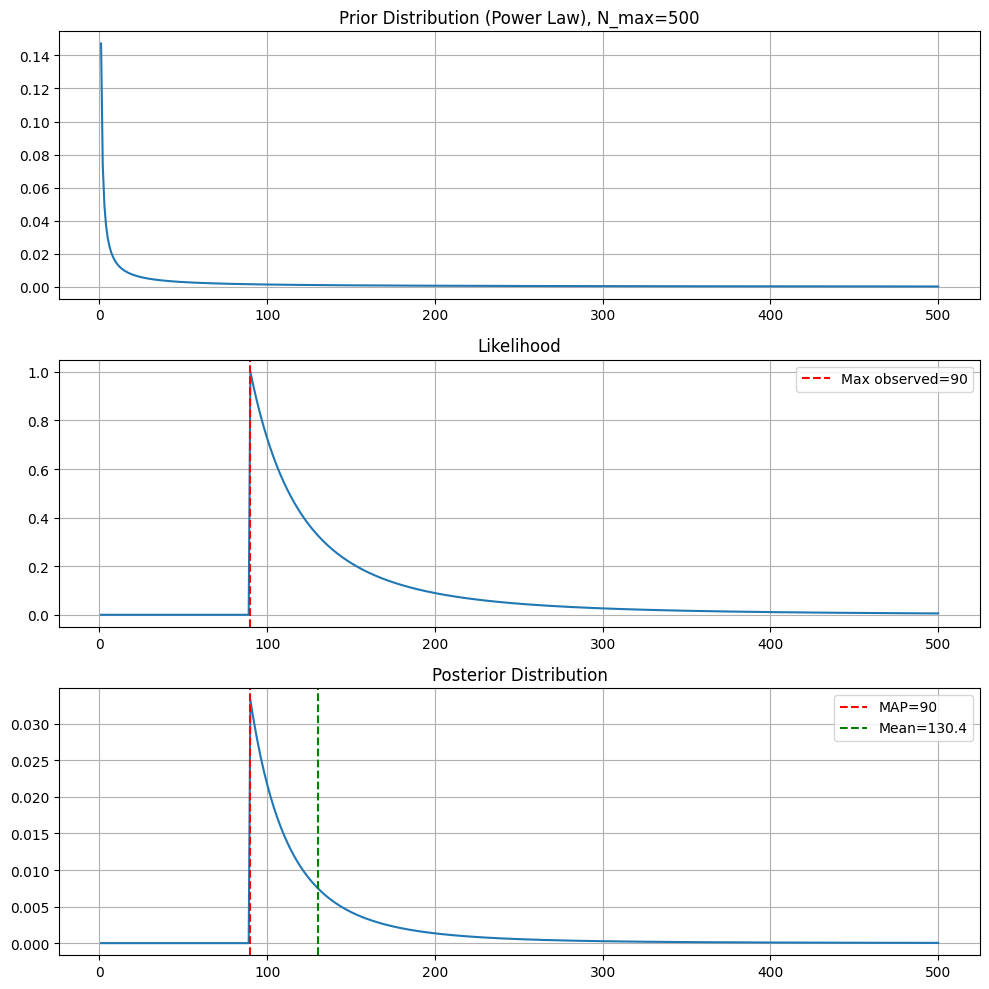


N_max = 1000
MAP            = 90
Posterior Mean = 132.92


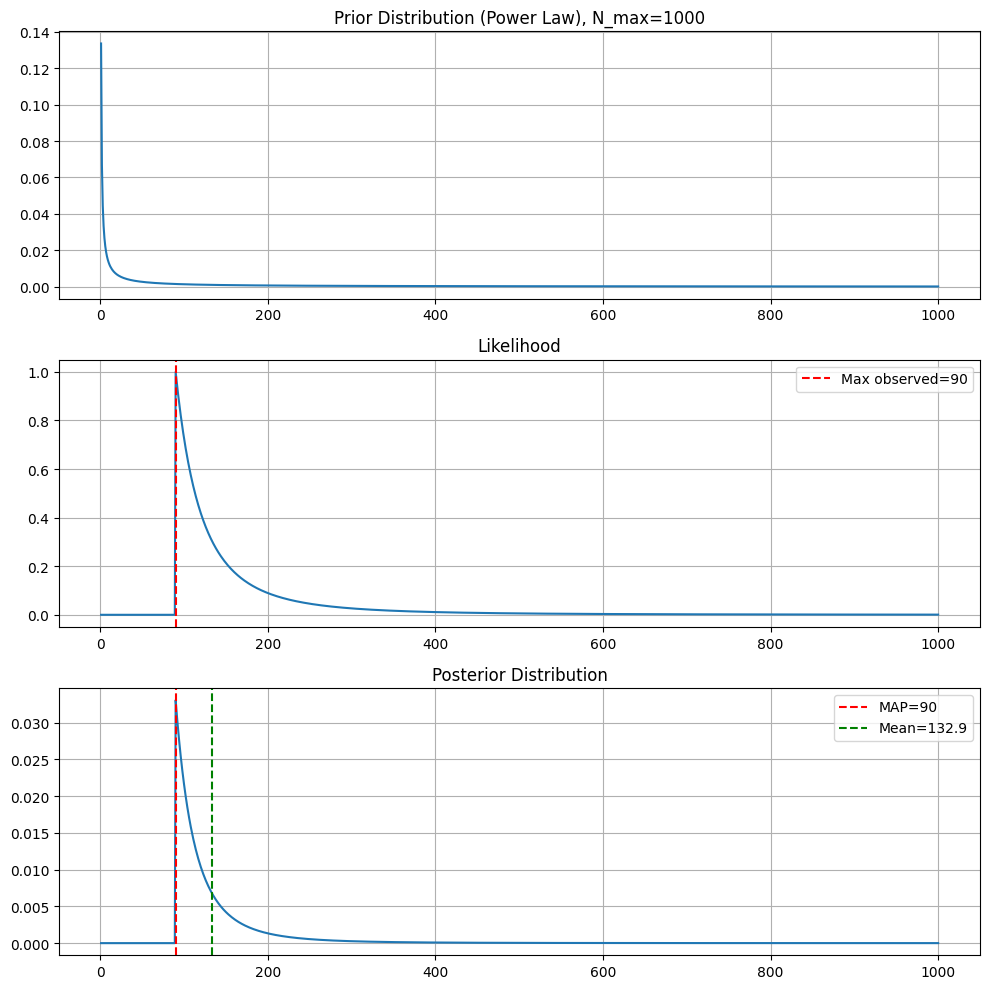


N_max = 2000
MAP            = 90
Posterior Mean = 133.63


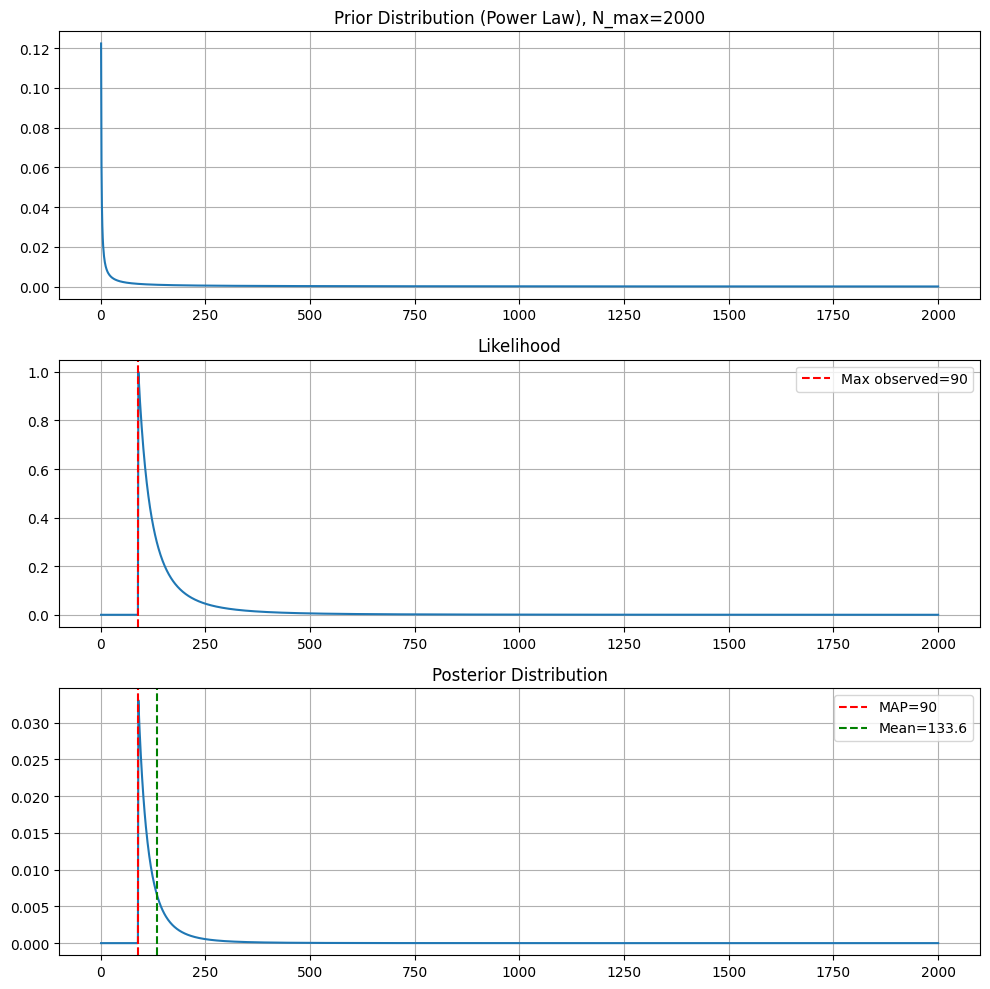

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# ------------------------------------
# 観測データ
# ------------------------------------
observed = [30, 60, 90]

m = max(observed)
k = len(observed)

# ------------------------------------
# 上限ごとに計算
# ------------------------------------
for N_max in [500, 1000, 2000]:

    N = np.arange(1, N_max + 1)

    # -------------------------
    # 事前分布（べき乗則）
    # P(N) ∝ 1/N
    # -------------------------
    prior = 1 / N
    prior = prior / prior.sum()

    # -------------------------
    # 尤度
    # -------------------------
    likelihood = np.zeros_like(N, dtype=float)

    mask = N >= m

    likelihood[mask] = 1 / comb(N[mask], k)

    # グラフ用に正規化
    likelihood_plot = likelihood / likelihood.max()

    # -------------------------
    # 事後分布
    # -------------------------
    posterior = prior * likelihood
    posterior = posterior / posterior.sum()

    # -------------------------
    # MAP
    # -------------------------
    map_estimate = N[np.argmax(posterior)]

    # -------------------------
    # 事後期待値
    # -------------------------
    posterior_mean = np.sum(N * posterior)

    print(f"\nN_max = {N_max}")
    print(f"MAP            = {map_estimate}")
    print(f"Posterior Mean = {posterior_mean:.2f}")

    # -------------------------
    # グラフ
    # -------------------------
    fig, ax = plt.subplots(
        3, 1,
        figsize=(10, 10)
    )

    # Prior
    ax[0].plot(N, prior)
    ax[0].set_title(
        f"Prior Distribution (Power Law), N_max={N_max}"
    )
    ax[0].grid(True)

    # Likelihood
    ax[1].plot(N, likelihood_plot)
    ax[1].axvline(
        m,
        color='red',
        linestyle='--',
        label=f'Max observed={m}'
    )
    ax[1].set_title(
        "Likelihood"
    )
    ax[1].legend()
    ax[1].grid(True)

    # Posterior
    ax[2].plot(N, posterior)

    ax[2].axvline(
        map_estimate,
        color='red',
        linestyle='--',
        label=f'MAP={map_estimate}'
    )

    ax[2].axvline(
        posterior_mean,
        color='green',
        linestyle='--',
        label=f'Mean={posterior_mean:.1f}'
    )

    ax[2].set_title(
        "Posterior Distribution"
    )

    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()

### 3.5 信頼区間

### 3.6 累積分布関数


N_max = 500
MAP            = 90
Posterior Mean = 130.40
90% Credible Interval = [91, 234]


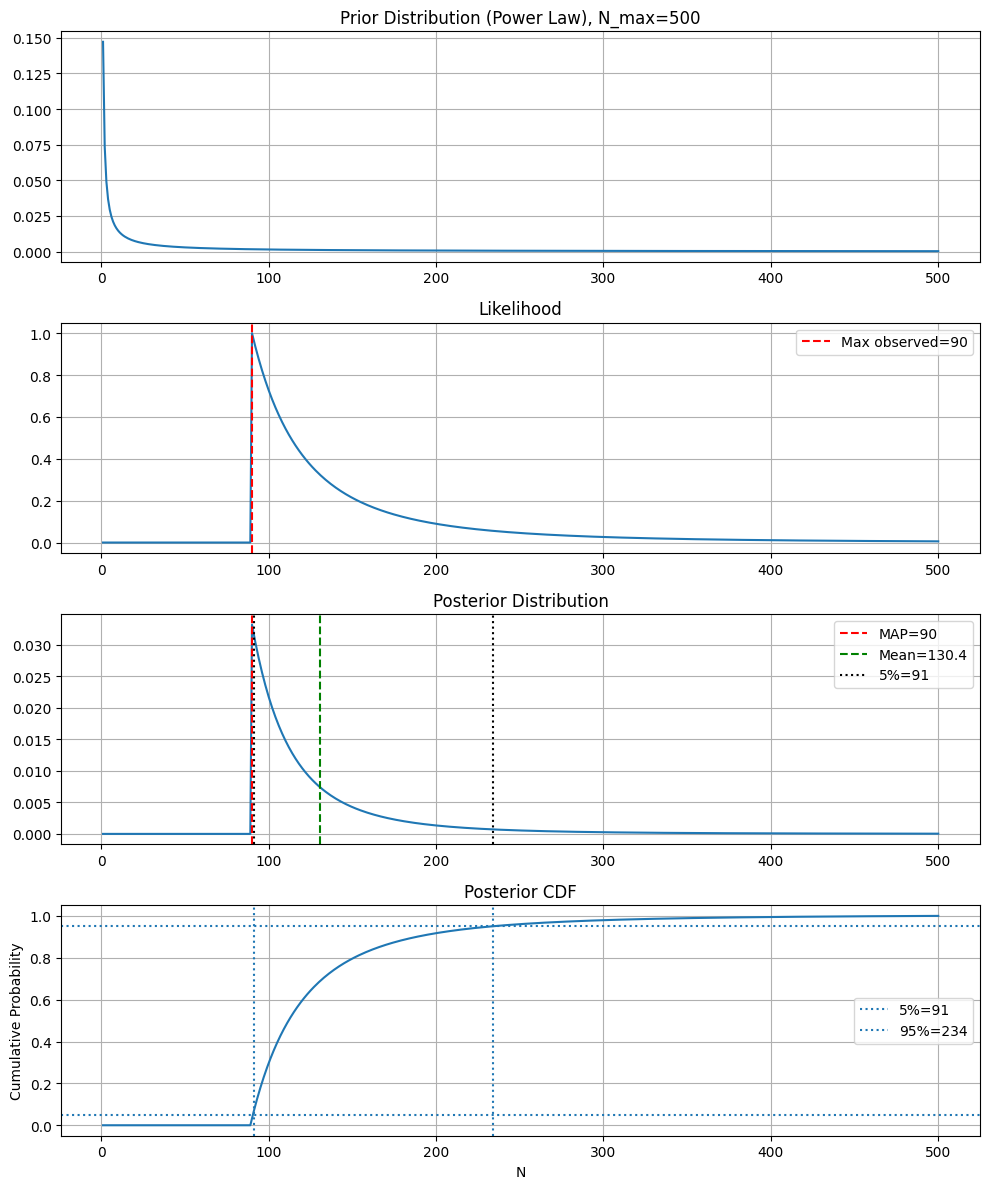


N_max = 1000
MAP            = 90
Posterior Mean = 132.92
90% Credible Interval = [91, 241]


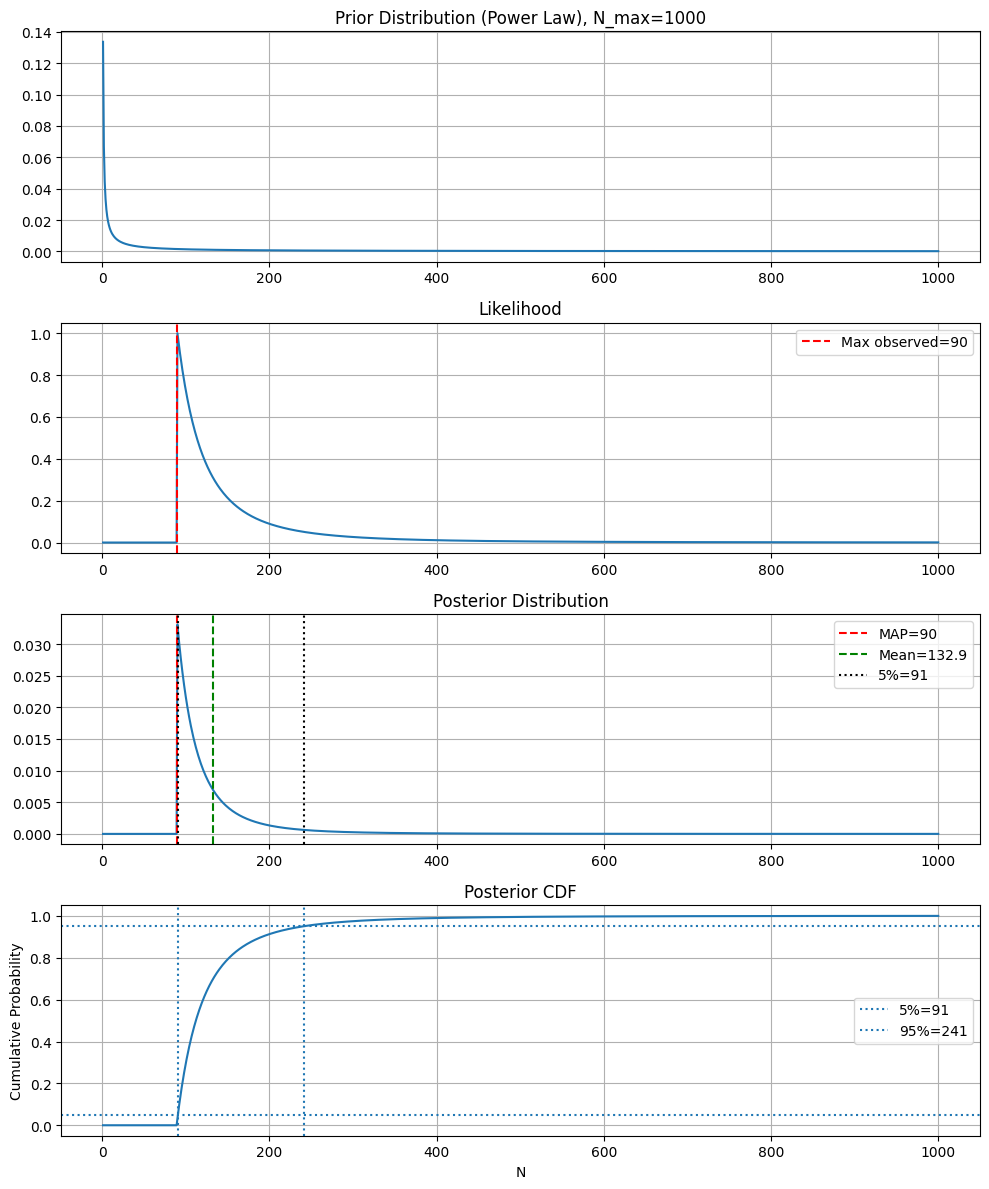


N_max = 2000
MAP            = 90
Posterior Mean = 133.63
90% Credible Interval = [91, 242]


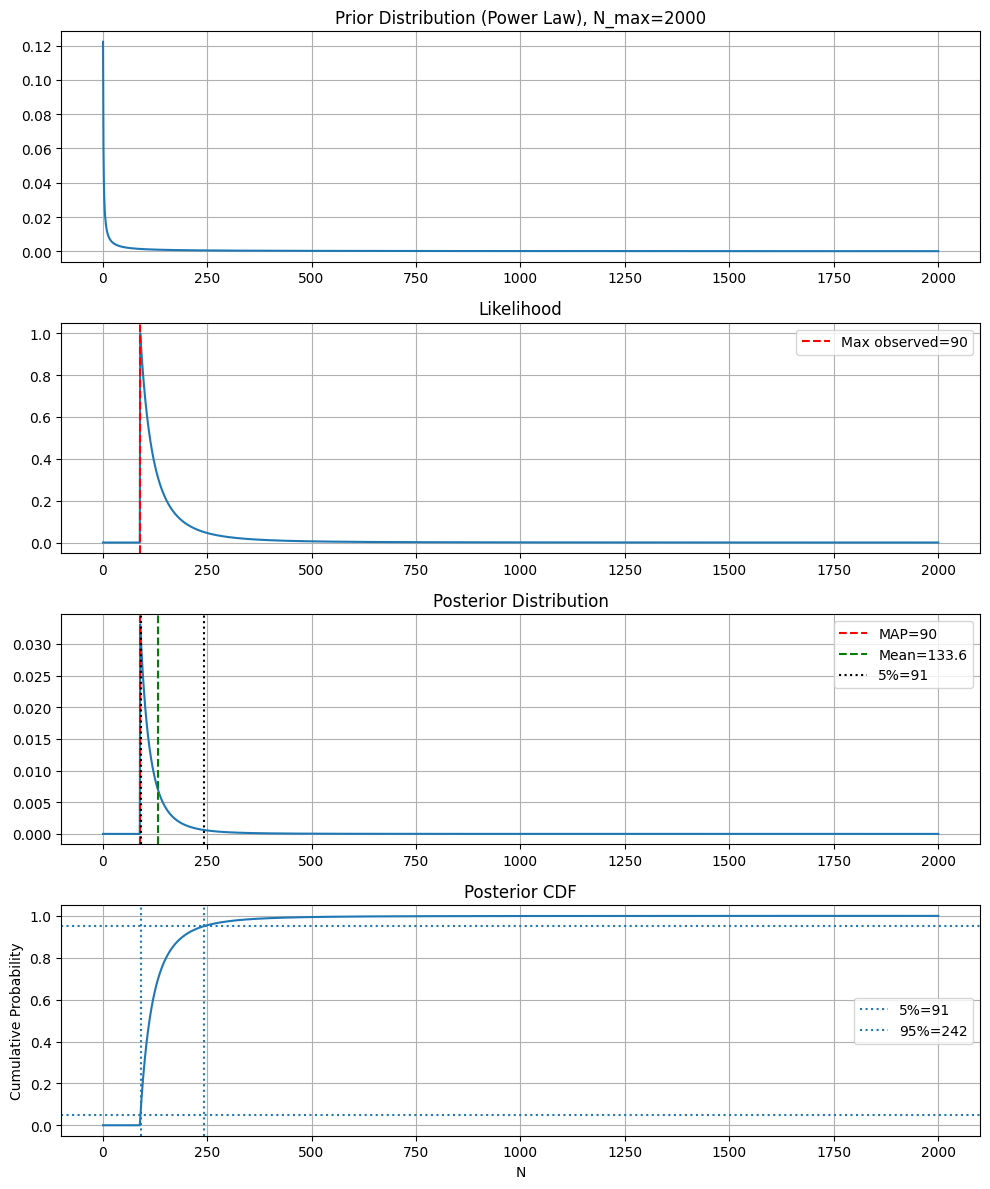

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# ------------------------------------
# 観測データ
# ------------------------------------
observed = [30, 60, 90]

m = max(observed)
k = len(observed)

# ------------------------------------
# 上限ごとに計算
# ------------------------------------
for N_max in [500, 1000, 2000]:

    N = np.arange(1, N_max + 1)

    # -------------------------
    # 事前分布（べき乗則）
    # -------------------------
    prior = 1 / N
    prior /= prior.sum()

    # -------------------------
    # 尤度
    # -------------------------
    likelihood = np.zeros_like(N, dtype=float)

    mask = N >= m
    likelihood[mask] = 1 / comb(N[mask], k)

    likelihood_plot = likelihood / likelihood.max()

    # -------------------------
    # 事後分布
    # -------------------------
    posterior = prior * likelihood
    posterior /= posterior.sum()

    # -------------------------
    # CDF
    # -------------------------
    cdf = np.cumsum(posterior)

    # -------------------------
    # MAP
    # -------------------------
    map_estimate = N[np.argmax(posterior)]

    # -------------------------
    # 事後期待値
    # -------------------------
    posterior_mean = np.sum(N * posterior)

    # -------------------------
    # 5%点、95%点
    # -------------------------
    low = N[np.searchsorted(cdf, 0.05)]
    high = N[np.searchsorted(cdf, 0.95)]

    print(f"\nN_max = {N_max}")
    print(f"MAP            = {map_estimate}")
    print(f"Posterior Mean = {posterior_mean:.2f}")
    print(f"90% Credible Interval = [{low}, {high}]")

    # -------------------------
    # グラフ
    # -------------------------
    fig, ax = plt.subplots(4, 1, figsize=(10, 12))

    # Prior
    ax[0].plot(N, prior)
    ax[0].set_title(
        f"Prior Distribution (Power Law), N_max={N_max}"
    )
    ax[0].grid(True)

    # Likelihood
    ax[1].plot(N, likelihood_plot)
    ax[1].axvline(
        m,
        color='red',
        linestyle='--',
        label=f'Max observed={m}'
    )
    ax[1].set_title("Likelihood")
    ax[1].legend()
    ax[1].grid(True)

    # Posterior
    ax[2].plot(N, posterior)

    ax[2].axvline(
        map_estimate,
        color='red',
        linestyle='--',
        label=f'MAP={map_estimate}'
    )

    ax[2].axvline(
        posterior_mean,
        color='green',
        linestyle='--',
        label=f'Mean={posterior_mean:.1f}'
    )

    ax[2].axvline(
        low,
        color='black',
        linestyle=':',
        label=f'5%={low}'
    )

    ax[2].axvline(
        high,
        color='black',
        linestyle=':'
    )

    ax[2].set_title("Posterior Distribution")
    ax[2].legend()
    ax[2].grid(True)

    # CDF
    ax[3].plot(N, cdf)

    ax[3].axhline(
        0.05,
        linestyle=':'
    )

    ax[3].axhline(
        0.95,
        linestyle=':'
    )

    ax[3].axvline(
        low,
        linestyle=':',
        label=f'5%={low}'
    )

    ax[3].axvline(
        high,
        linestyle=':',
        label=f'95%={high}'
    )

    ax[3].set_title("Posterior CDF")
    ax[3].set_xlabel("N")
    ax[3].set_ylabel("Cumulative Probability")
    ax[3].legend()
    ax[3].grid(True)

    plt.tight_layout()
    plt.show()

### 3.7 ドイツ軍戦車問題

### 3.8 議論


### 3.9 練習問題

サイズバイアス

$ P(N) $

$ P^{*}(N) \propto N P(N) $

#### 冪乗則の場合

$ P(N) \propto 1/N $

$ P^{*} \propto N \times 1/N = 1 $ 